In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py 
import sys 
import os 

plt.style.use('../../utils/dune.mplstyle')


In [2]:
file='/pscratch/sd/l/lmlepin/grid_output/AmBe_top_mod2_test_03-17/EDEPSIM/2x2_QGSP_BERT_HP_AmBe_1773786323_0_TIME_MOD.EDEPSIM.hdf5'
h5_file = h5py.File(file,'r') 
vertex = h5_file['vertices']
traj = h5_file['trajectories']
seg = h5_file['segments']
print(h5_file.keys())
print(f"Number of events: {len(vertex)}")

<KeysViewHDF5 ['segments', 'trajectories', 'vertices']>
Number of events: 76


In [3]:
vertex['event_id']

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76], dtype=uint32)

In [4]:
capture_times = []
total_gamma_E = []
gamma_E = []
n_gammas = [] 

In [5]:


for ev in vertex['event_id']:
    my_vert = vertex[vertex['event_id']==ev]
    my_traj = traj[traj['event_id']==ev]

    ar41_traj = my_traj[(my_traj['pdg_id']==1000180410) & (my_traj['start_process']==4) & (my_traj['start_subprocess']==131)]
    ar41_traj_id = ar41_traj['parent_id']



    capture_times.extend(my_traj[(my_traj['pdg_id']==1000180410) & (my_traj['start_process']==4) & (my_traj['start_subprocess']==131) ]['t_start'] - my_vert['t_event'])
    gamma_E.extend(my_traj[(my_traj['pdg_id']==22) & 
                           (my_traj['parent_id']==ar41_traj_id) &
                           (my_traj['start_process']==4) & 
                           (my_traj['start_subprocess']==131)]['E_start'])
    
    n_gammas.append(len(my_traj[(my_traj['pdg_id']==22) & 
                                (my_traj['parent_id']==ar41_traj_id) &
                                (my_traj['start_process']==4) & 
                                (my_traj['start_subprocess']==131)]['E_start']))
    
    total_gamma_E.append(np.sum(my_traj[(my_traj['pdg_id']==22) &
                                        (my_traj['parent_id']==ar41_traj_id) &
                                         (my_traj['start_process']==4) & 
                                         (my_traj['start_subprocess']==131)]['E_start']))

    


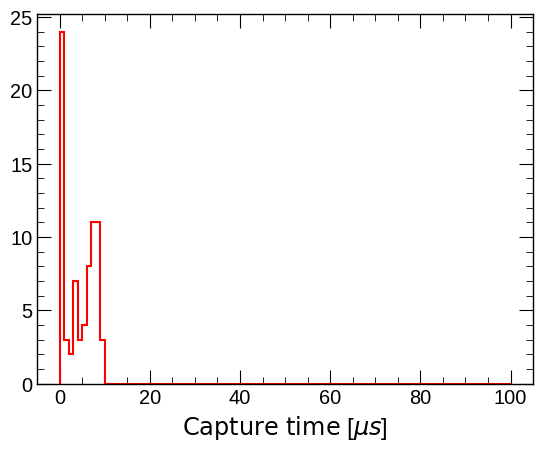

In [6]:
plt.hist(capture_times,bins=100,range=(0.,100.),histtype='step',color='red')
plt.xlabel(r'$\text{Capture time}$ [$\mu s$]')
plt.show()

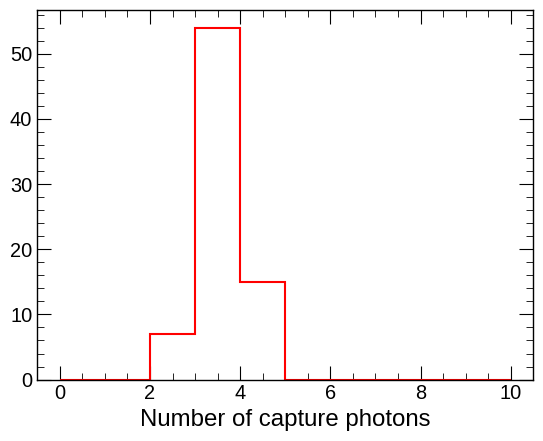

In [7]:
binning = np.linspace(0,10.,11)
plt.hist(n_gammas,bins=binning,histtype='step',color='red')
plt.xlabel('Number of capture photons')
plt.show()

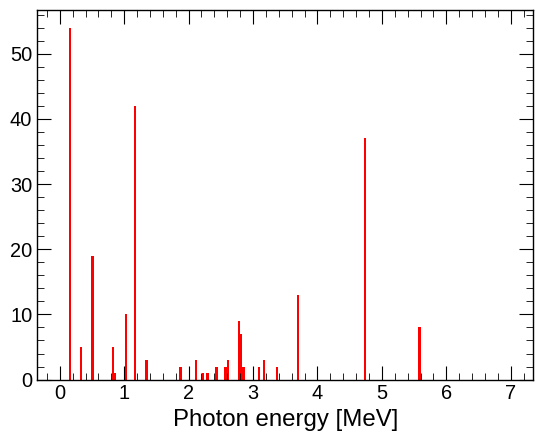

In [8]:
plt.hist(gamma_E,bins=200,range=(0.,7.),color='red')
plt.xlabel('Photon energy [MeV]')
plt.show()

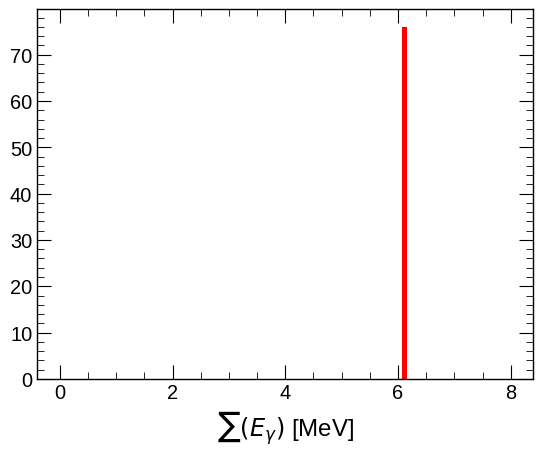

In [9]:
plt.hist(total_gamma_E,bins=100,range=(0.,8.),color='red')
plt.xlabel(r'$\sum(E_{\gamma})$ [MeV]')
plt.show()